# 🤖 Machine Learning — PP1: Clusterização de Municípios Brasileiros
> **Projeto Brasil em Foco — PISI3 — UFRPE 2026.1**
>
> 👥 **Autores**: Arthur Barbosa, Danielly Nunes, Gabriel Sabino, Isadora Morais, Luiz Vinícius

---

## 🎯 Objetivo

Este notebook implementa a **Pergunta de Pesquisa 1 (PP1)**:

> *Como técnicas de aprendizado não supervisionado podem ser utilizadas para identificar padrões e agrupar cidades brasileiras com potencial turístico semelhante?*

Seguindo a metodologia **KDD (Knowledge Discovery in Databases)**, aplicamos algoritmos de clusterização para segmentar os municípios brasileiros em grupos com perfis turísticos similares, identificando padrões ocultos — incluindo as chamadas **Joias Escondidas**: cidades com alta qualidade de vida e baixa infraestrutura turística.

---

## 📋 Etapas do KDD neste notebook

| Fase | Descrição |
|------|-----------|
| **Fase 1** | Seleção e preparação das features |
| **Fase 2** | Pré-processamento (normalização, tratamento de outliers) |
| **Fase 3** | Mineração — Aplicação dos algoritmos de clusterização |
| **Fase 4** | Avaliação — Cotovelo, Silhueta e comparação entre algoritmos |
| **Fase 5** | Interpretação dos clusters e identificação das Joias Escondidas |

---
## 📦 Importação das Bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — pré-processamento
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA

# Sklearn — algoritmos de clusterização
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Sklearn — métricas de avaliação
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

# Configurações visuais
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (12, 6)

SEED = 42
print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


---
## 📥 Carregamento dos Dados

In [ ]:
# ⚠️ Ajuste o caminho conforme seu ambiente (Colab, local, etc.)
# No Colab:
# from google.colab import drive
# drive.mount('/content/drive')
# df_raw = pd.read_csv('/content/drive/MyDrive/brazilian_cities/BRAZIL_CITIES.csv', sep=';', encoding='latin-1')

df_raw = pd.read_csv('BRAZIL_CITIES.csv', sep=';', encoding='latin-1')

# Padronização dos nomes de colunas (mesma lógica da EDA)
df_raw.columns = (
    df_raw.columns
    .str.lower()
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

print(f'✅ Dataset carregado: {df_raw.shape[0]} municípios | {df_raw.shape[1]} variáveis')
df_raw.head(3)

✅ Dataset carregado: 5573 municípios | 81 variáveis


,city,state,capital,ibge_res_pop,ibge_res_pop_bras,ibge_res_pop_estr,ibge_du,ibge_du_urban,ibge_du_rural,ibge_pop,...,pu_bank,pr_assets,pu_assets,cars,motorcycles,wheeled_tractor,uber,mac,walmart,post_offices
0,Abadia De GoiÃ¡s,GO,0,6876.0,6876.0,0.0,2137.0,1546.0,591.0,5300.0,...,NaN,NaN,NaN,2158.0,1246.0,0.0,NaN,NaN,NaN,1.0
1,Abadia Dos Dourados,MG,0,6704.0,6704.0,0.0,2328.0,1481.0,847.0,4154.0,...,NaN,NaN,NaN,2227.0,1142.0,0.0,NaN,NaN,NaN,1.0
2,AbadiÃ¢nia,GO,0,15757.0,15609.0,148.0,4655.0,3233.0,1422.0,10656.0,...,1.0,33724584.0,67091904.0,2838.0,1426.0,0.0,NaN,NaN,NaN,3.0


---
## 🔧 Fase 1 — Seleção e Engenharia de Features

### Critérios de seleção

Seguindo a metodologia KDD, selecionamos variáveis que representem as **três dimensões do perfil turístico** identificadas na EDA:

| Dimensão | Variáveis |
|----------|-----------|
| **Econômica** | `gdp_capita`, `idhm` |
| **Infraestrutura Turística** | `leitos_1000hab`, `hoteis_por_hab` |
| **Conectividade e Serviços** | `servicos_por_hab`, `agencias_total`, `uber` |
| **Demográfica** | `estimated_pop` |

> **Nota**: Usamos variáveis normalizadas por habitante (criadas na EDA) para evitar que o tamanho populacional domine os clusters.

In [ ]:
df = df_raw.copy()

# ── Features derivadas (replicando a EDA) ──────────────────────────────────
df['estimated_pop'] = pd.to_numeric(df['estimated_pop'], errors='coerce')
df['hotels']        = pd.to_numeric(df['hotels'], errors='coerce').fillna(0)
df['beds']          = pd.to_numeric(df['beds'], errors='coerce').fillna(0)
df['comp_i']        = pd.to_numeric(df['comp_i'], errors='coerce').fillna(0)
df['pr_agencies']   = pd.to_numeric(df['pr_agencies'], errors='coerce').fillna(0)
df['pu_agencies']   = pd.to_numeric(df['pu_agencies'], errors='coerce').fillna(0)
df['uber']          = pd.to_numeric(df['uber'], errors='coerce').fillna(0)
df['gdp_capita']    = pd.to_numeric(df['gdp_capita'], errors='coerce')
df['idhm']          = pd.to_numeric(df['idhm'], errors='coerce')

pop = df['estimated_pop'].replace(0, np.nan)

df['leitos_1000hab']   = (df['beds']   / pop * 1000)
df['hoteis_por_hab']   = (df['hotels'] / pop * 1000)
df['servicos_por_hab'] = (df['comp_i'] / pop * 1000)
df['agencias_total']   = df['pr_agencies'] + df['pu_agencies']

# ── Seleção das features para clusterização ───────────────────────────────
FEATURES = [
    'gdp_capita',
    'idhm',
    'leitos_1000hab',
    'hoteis_por_hab',
    'servicos_por_hab',
    'agencias_total',
    'uber',
    'estimated_pop'
]

# ── Filtragem: manter apenas linhas com dados suficientes ─────────────────
df_ml = df[['city', 'state'] + FEATURES].dropna(subset=['gdp_capita', 'idhm', 'estimated_pop'])
df_ml = df_ml.fillna(0)  # demais nulos → 0 (cidades sem infraestrutura registrada)

print(f'✅ Dataset para ML: {df_ml.shape[0]} municípios | {len(FEATURES)} features')
print(f'   Municípios removidos por nulos: {df_raw.shape[0] - df_ml.shape[0]}')
df_ml[FEATURES].describe().round(2)

✅ Dataset para ML: 5564 municípios | 8 features
   Municípios removidos por nulos: 9


,gdp_capita,idhm,leitos_1000hab,hoteis_por_hab,servicos_por_hab,agencias_total,uber,estimated_pop
count,5564.00,5564.00,5564.00,5564.00,5564.00,5564.00,5564.00,5564.00
mean,21121.63,0.66,0.99,0.02,1.03,3.73,0.02,37461.82
std,20318.92,0.07,9.52,0.13,1.33,37.34,0.15,220085.64
min,3190.57,0.42,0.00,0.00,0.00,0.00,0.00,786.00
25%,9061.89,0.60,0.00,0.00,0.20,0.00,0.00,5453.00
50%,15869.62,0.66,0.00,0.00,0.69,1.00,0.00,11591.00
75%,26155.41,0.72,0.00,0.00,1.54,3.00,0.00,25306.50
max,314637.69,0.86,538.55,4.30,41.05,2319.00,1.00,12176866.00


---
## 🔧 Fase 2 — Pré-processamento

### 2.1 Tratamento de Outliers

Variáveis como `gdp_capita` e `leitos_1000hab` possuem outliers extremos (identificados na EDA — ex: Paulínia com PIB de R$314k). Aplicamos **Winsorização** no percentil 99 para limitar a influência desses valores sem removê-los.

✅ Winsorização aplicada (p1–p99) nas variáveis com outliers extremos


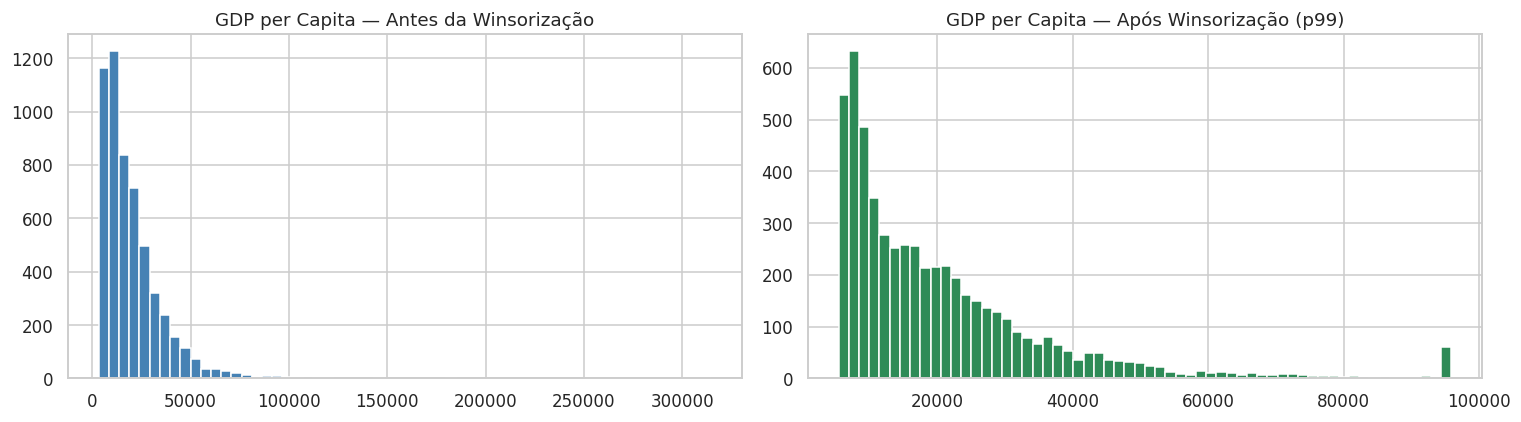

Fonte: elaborado pelos autores (2026).


In [6]:
from scipy.stats import mstats

df_proc = df_ml.copy()

# Winsorização no percentil 1-99 para variáveis com outliers extremos
COLS_WINSORIZE = ['gdp_capita', 'leitos_1000hab', 'hoteis_por_hab',
                  'servicos_por_hab', 'agencias_total', 'estimated_pop']

for col in COLS_WINSORIZE:
    p01 = df_proc[col].quantile(0.01)
    p99 = df_proc[col].quantile(0.99)
    df_proc[col] = df_proc[col].clip(lower=p01, upper=p99)

print('✅ Winsorização aplicada (p1–p99) nas variáveis com outliers extremos')

# Visualização antes/depois do gdp_capita
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df_ml['gdp_capita'].hist(bins=60, ax=axes[0], color='steelblue')
axes[0].set_title('GDP per Capita — Antes da Winsorização')
df_proc['gdp_capita'].hist(bins=60, ax=axes[1], color='seagreen')
axes[1].set_title('GDP per Capita — Após Winsorização (p99)')
plt.tight_layout()
plt.savefig('fig_winsorization.png', dpi=110, bbox_inches='tight')
plt.show()
print('Fonte: elaborado pelos autores (2026).')

### 2.2 Normalização

Algoritmos baseados em distância (K-Means, Hierárquico) são sensíveis à escala das variáveis. Utilizamos **RobustScaler** — mais resistente a outliers residuais que o StandardScaler — para padronizar todas as features.

In [7]:
X = df_proc[FEATURES].values

# RobustScaler: usa mediana e IQR — mais robusto a outliers que StandardScaler
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

print('✅ Normalização aplicada com RobustScaler')
print(f'   Shape do array normalizado: {X_scaled.shape}')

# Verificação: média próxima de 0, desvio próximo de 1
df_scaled_check = pd.DataFrame(X_scaled, columns=FEATURES)
print('\nEstatísticas após normalização:')
df_scaled_check.describe().round(3)

✅ Normalização aplicada com RobustScaler
   Shape do array normalizado: (5564, 8)

Estatísticas após normalização:


,gdp_capita,idhm,leitos_1000hab,hoteis_por_hab,servicos_por_hab,agencias_total,uber,estimated_pop
count,5564.000,5564.000,5564.000,5564.000,5564.000,5564.000,5564.000,5564.000
mean,0.273,-0.049,0.639,0.013,0.225,0.479,0.022,0.885
std,0.938,0.605,2.292,0.046,0.747,1.700,0.148,2.976
min,-0.610,-2.076,0.000,0.000,-0.517,-0.333,0.000,-0.499
25%,-0.398,-0.555,0.000,0.000,-0.366,-0.333,0.000,-0.309
50%,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
75%,0.602,0.445,0.000,0.000,0.634,0.667,0.000,0.691
max,4.681,1.655,16.183,0.314,3.185,12.333,1.000,20.494
